In [17]:
import pandas as pd
import numpy as np


N = 10000


x = np.random.normal(size=N)
y = np.random.normal(x)
s = 1.*(y>-3.)*(y < 3.)

df = pd.DataFrame({"X": x, "Y": y, "S": s})


In [18]:
from statsmodels.api import OLS


df['intercept'] = 1.

model = OLS(exog=df[['X', 'intercept']], endog=df['Y'])
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     9869.
Date:                Sun, 16 Apr 2023   Prob (F-statistic):               0.00
Time:                        19:08:22   Log-Likelihood:                -14169.
No. Observations:               10000   AIC:                         2.834e+04
Df Residuals:                    9998   BIC:                         2.836e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
X              0.9813      0.010     99.343      0.000       0.962       1.001
intercept      0.0008      0.010      0.076      0.939      -0.019       0.020
==============================================================================
Omnibus:                        0.091   Durbin-Watson:                   1.994
Prob(Omnibus):                  0.955   Jarque-Bera (JB):                0.075
Skew:                           0.004   Prob(JB):                        0.963
Kurtosis:                       3.010   Cond. No.                         1.02
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='X', ylabel='Y'>

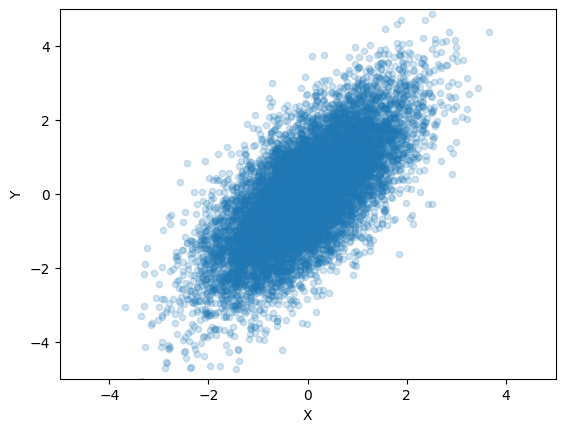

In [19]:
df.plot(x='X', y='Y', kind='scatter', alpha=0.2, xlim=(-5, 5), ylim=(-5, 5))

In [20]:
from statsmodels.api import OLS


df['intercept'] = 1.

s = 1

model = OLS(exog=df[df.S==s][['X', 'intercept']], 
            endog=df[df.S==s]['Y'])
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     7883.
Date:                Sun, 16 Apr 2023   Prob (F-statistic):               0.00
Time:                        19:08:24   Log-Likelihood:                -13217.
No. Observations:                9684   AIC:                         2.644e+04
Df Residuals:                    9682   BIC:                         2.645e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
X              0.8850      0.010     88.786      0.000       0.865       0.905
intercept     -0.0010      0.010     -0.105      0.916      -0.020       0.018
==============================================================================
Omnibus:                       13.169   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               11.372
Skew:                           0.019   Prob(JB):                      0.00339
Kurtosis:                       2.836   Cond. No.                         1.04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='X', ylabel='Y'>

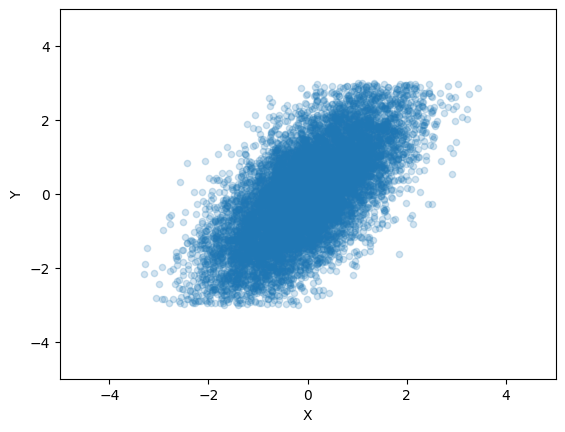

In [21]:
df[df.S == 1].plot(x='X', y='Y', kind='scatter', alpha=0.2, xlim=(-5, 5), ylim=(-5, 5))

<Axes: xlabel='X', ylabel='Y'>

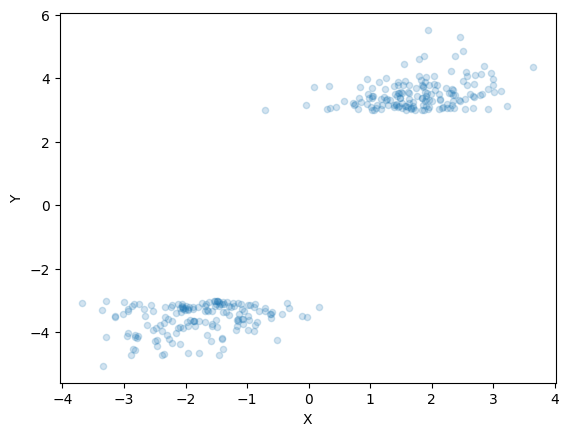

In [22]:
df[df.S == 0].plot(x='X', y='Y', kind='scatter', alpha=0.2)

In [23]:
df['residual'] = np.nan
df.loc[df.S==s, 'residual'] = result.resid

<Axes: xlabel='X', ylabel='residual'>

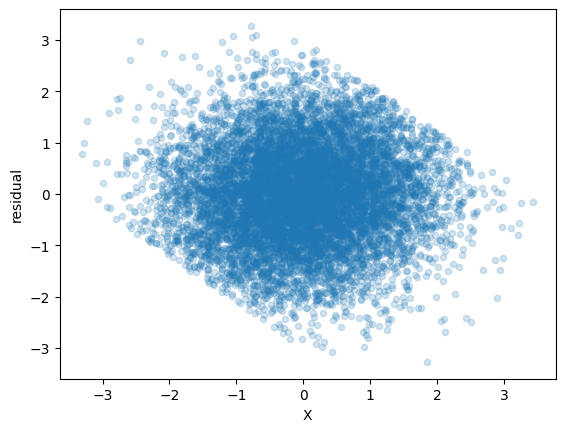

In [24]:
df[df.S==1].plot(x='X', y='residual', kind='scatter', alpha=0.2)

# Click-Through Rates

In [64]:
N = 10000

i = np.random.poisson(100, size=N)
x = np.random.normal(10, 1, size=N)
ctr = np.random.beta(x, 50, size=N)
c = np.random.binomial(i, p=ctr)

df = pd.DataFrame({'impressions': i, 'x': x, 'ctr': ctr, 'clicks': c})

In [65]:
df['ctr_measured'] = df['clicks'] / df['impressions']

In [66]:
df[['x', 'impressions', 'clicks', 'ctr', 'ctr_measured']]

,x,impressions,clicks,ctr,ctr_measured
0,9.092991,100,11,0.123829,0.110000
1,9.965331,104,11,0.083177,0.105769
2,10.324374,93,22,0.205880,0.236559
3,10.031020,92,17,0.198754,0.184783
4,9.742044,90,16,0.208941,0.177778
...,...,...,...,...,...
9995,7.582554,103,11,0.125319,0.106796
9996,8.773173,98,11,0.089184,0.112245
9997,10.346741,89,10,0.153888,0.112360
9998,10.009970,110,29,0.168579,0.263636


<Axes: xlabel='x', ylabel='ctr_measured'>

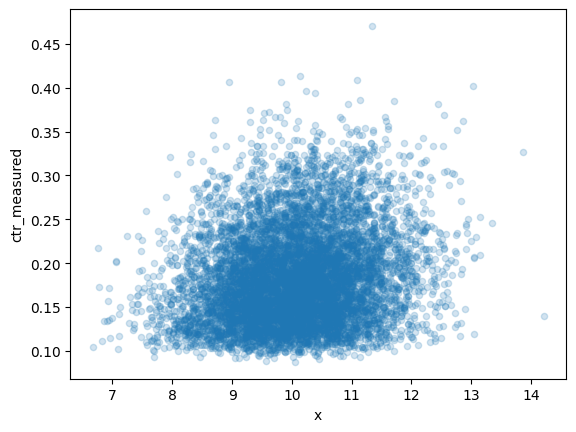

In [72]:
df.plot('x', 'ctr_measured', kind='scatter', alpha=0.2)

In [68]:
from statsmodels.api import OLS


df['intercept'] = 1.

model = OLS(exog=df[['x', 'intercept']], endog=df['ctr'])
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    ctr   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     849.1
Date:                Sun, 16 Apr 2023   Prob (F-statistic):          3.14e-179
Time:                        19:25:37   Log-Likelihood:                 16169.
No. Observations:               10000   AIC:                        -3.233e+04
Df Residuals:                    9998   BIC:                        -3.232e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x              0.0141      0.000     29.139      0.000       0.013       0.015
intercept      0.0255      0.005      5.245      0.000       0.016       0.035
==============================================================================
Omnibus:                      265.890   Durbin-Watson:                   2.020
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              286.896
Skew:                           0.413   Prob(JB):                     5.03e-63
Kurtosis:                       3.088   Cond. No.                         103.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [69]:
from statsmodels.api import OLS


df['intercept'] = 1.

model = OLS(exog=df[['x', 'intercept']], endog=df['ctr_measured'])
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           ctr_measured   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     544.9
Date:                Sun, 16 Apr 2023   Prob (F-statistic):          2.10e-117
Time:                        19:25:37   Log-Likelihood:                 13798.
No. Observations:               10000   AIC:                        -2.759e+04
Df Residuals:                    9998   BIC:                        -2.758e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x              0.0143      0.001     23.344      0.000       0.013       0.016
intercept      0.0235      0.006      3.819      0.000       0.011       0.036
==============================================================================
Omnibus:                      295.073   Durbin-Watson:                   2.011
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              321.191
Skew:                           0.437   Prob(JB):                     1.80e-70
Kurtosis:                       3.073   Cond. No.                         103.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [70]:
from statsmodels.api import OLS

df = df[df.clicks > 10]


df['intercept'] = 1.

model = OLS(exog=df[['x', 'intercept']], endog=df['ctr_measured'])
result = model.fit()
result.summary()

/var/folders/9z/gtw2cdv96hjcgnxx1cdg0xh40000gn/T/ipykernel_19847/3958809584.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['intercept'] = 1.


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           ctr_measured   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.033
Method:                 Least Squares   F-statistic:                     281.8
Date:                Sun, 16 Apr 2023   Prob (F-statistic):           3.25e-62
Time:                        19:25:38   Log-Likelihood:                 12637.
No. Observations:                8293   AIC:                        -2.527e+04
Df Residuals:                    8291   BIC:                        -2.526e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x              0.0099      0.001     16.786      0.000       0.009       0.011
intercept      0.0840      0.006     14.063      0.000       0.072       0.096
==============================================================================
Omnibus:                      695.468   Durbin-Watson:                   2.015
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              880.199
Skew:                           0.773   Prob(JB):                    7.36e-192
Kurtosis:                       3.397   Cond. No.                         105.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""